# Pancreas CT Classification: Raw vs. Preprocessed Features

This notebook will conduct an experiment to compare the classification accuracy of an SVM model using two different feature extraction pipelines:

1.  **Raw Pipeline:** Combined features (LBP, GLCM, Fourier, HOG) extracted directly from a raw 300x300 center-cropped ROI.
2.  **Hybrid A Pipeline:** Combined features extracted from an ROI that has first been preprocessed with **CT Windowing** and **CLAHE**.

In [1]:
import numpy as np
import os
import glob
import cv2
from skimage import exposure, feature
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.stats import entropy, skew, kurtosis
import matplotlib.pyplot as plt

%matplotlib inline

## Part 1: Helper Functions & Setup

First, we define all constants and helper functions. We will create *generic* feature extractors that take an ROI as an argument. This lets us use two different "master" functions to feed them either raw ROIs or preprocessed ROIs.

In [2]:
# --- 1. CONSTANTS ---
CENTER_CROP_SIZE = 300
HU_RANGE_MIN = -200
HU_RANGE_MAX = 200

# Preprocessing (Hybrid A) Constants
WINDOW_LEVEL = 40
WINDOW_WIDTH = 400
CLIP_LIMIT = 0.01
KERNEL_SIZE = (80, 80)

# Feature Extractor Constants
LBP_RADIUS = 3
LBP_N_POINTS = 8 * LBP_RADIUS
LBP_METHOD = 'uniform'

GLCM_LEVELS = 16
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]

FOURIER_NUM_RINGS = 4
FOURIER_RING_RADII = np.linspace(0, CENTER_CROP_SIZE / 2, FOURIER_NUM_RINGS + 1)

HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (100, 100)
HOG_CELLS_PER_BLOCK = (2, 2)

# --- 2. PREPROCESSING FUNCTIONS ---

def apply_window(image_data, window_level, window_width):
    """Applies a custom HU window to the 8-bit image data."""
    sim_hu = (image_data / 255.0) * (HU_RANGE_MAX - HU_RANGE_MIN) + HU_RANGE_MIN
    HU_min = window_level - (window_width / 2)
    HU_max = window_level + (window_width / 2)
    windowed_data = np.clip(sim_hu, HU_min, HU_max)
    scaled_data = (windowed_data - HU_min) / (HU_max - HU_min)
    scaled_data = (scaled_data * 255).astype(np.uint8)
    return scaled_data

def get_raw_roi(image_path, crop_size=CENTER_CROP_SIZE):
    """Loads the raw 8-bit image and returns the central ROI."""
    try:
        img_8bit = np.array(Image.open(image_path).convert('L'))
        H, W = img_8bit.shape
        start_h, end_h = H // 2 - crop_size // 2, H // 2 + crop_size // 2
        start_w, end_w = W // 2 - crop_size // 2, W // 2 + crop_size // 2
        if start_h < 0 or start_w < 0 or end_h > H or end_w > W:
             raise ValueError("Image too small for crop.")
        return img_8bit[start_h:end_h, start_w:end_w]
    except Exception as e:
        return np.array([])

def preprocess_and_roi_hybrid_a(image_path, crop_size=CENTER_CROP_SIZE):
    """Hybrid A: Applies Windowing and CLAHE, then returns ROI."""
    try:
        img_8bit = np.array(Image.open(image_path).convert('L'))
        H, W = img_8bit.shape
        
        # 1. Windowing
        windowed = apply_window(img_8bit, WINDOW_LEVEL, WINDOW_WIDTH)
        float_img = windowed / 255.0
        
        # 2. CLAHE
        clahe = exposure.equalize_adapthist(float_img, clip_limit=CLIP_LIMIT, kernel_size=KERNEL_SIZE)
        clahe_8bit = (clahe * 255).astype(np.uint8)
        
        # 3. ROI Extraction
        start_h, end_h = H // 2 - crop_size // 2, H // 2 + crop_size // 2
        start_w, end_w = W // 2 - crop_size // 2, W // 2 + crop_size // 2
        if start_h < 0 or start_w < 0 or end_h > H or end_w > W:
             raise ValueError("Image too small for crop.")
        return clahe_8bit[start_h:end_h, start_w:end_w]
    except Exception as e:
        return np.array([])

# --- 3. GENERIC FEATURE EXTRACTORS (TAKE ROI AS INPUT) ---

def extract_lbp_features(roi):
    try:
        lbp = feature.local_binary_pattern(roi, P=LBP_N_POINTS, R=LBP_RADIUS, method=LBP_METHOD)
        n_bins = int(lbp.max() + 1)
        hist, _ = np.histogram(lbp.ravel(), density=True, bins=n_bins, range=(0, n_bins))
        return hist
    except Exception: return np.array([])

def extract_glcm_features(roi):
    try:
        glcm_input = (roi // (256 / GLCM_LEVELS)).astype(np.uint8)
        glcm = feature.graycomatrix(glcm_input, distances=GLCM_DISTANCES, angles=GLCM_ANGLES, levels=GLCM_LEVELS, symmetric=True, normed=True)
        contrast = feature.graycoprops(glcm, 'contrast').mean()
        energy = feature.graycoprops(glcm, 'energy').mean()
        homogeneity = feature.graycoprops(glcm, 'homogeneity').mean()
        return np.array([contrast, energy, homogeneity])
    except Exception: return np.array([])

def extract_fourier_features(roi):
    try:
        roi_float = roi.astype(np.float64)
        f = np.fft.fft2(roi_float)
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = np.abs(fshift)**2
        rows, cols = magnitude_spectrum.shape
        crow, ccol = rows // 2, cols // 2
        y, x = np.ogrid[-crow:rows - crow, -ccol:cols - ccol]
        r = np.sqrt(x*x + y*y)
        feature_vector = []
        for i in range(FOURIER_NUM_RINGS):
            r_min, r_max = FOURIER_RING_RADII[i], FOURIER_RING_RADII[i+1]
            ring_mask = np.logical_and(r >= r_min, r < r_max)
            ring_values = magnitude_spectrum[ring_mask]
            if len(ring_values) > 0:
                ring_prob = ring_values / np.sum(ring_values)
                feature_vector.extend([np.sum(ring_values), np.mean(ring_values), entropy(ring_prob + 1e-10)])
            else: feature_vector.extend([0.0, 0.0, 0.0])
        return np.array(feature_vector)
    except Exception: return np.array([])

def extract_hog_features(roi):
    try:
        roi_float = roi / 255.0
        hog_features = feature.hog(roi_float, orientations=HOG_ORIENTATIONS, pixels_per_cell=HOG_PIXELS_PER_CELL, cells_per_block=HOG_CELLS_PER_BLOCK, transform_sqrt=False, feature_vector=True, block_norm='L2-Hys')
        return hog_features
    except Exception: return np.array([])

# --- 4. MASTER COMPILER & CLASSIFICATION RUNNER ---

def compile_dataset_features(base_data_dir, preprocessing_function):
    """Master function to compile features using a given preprocessing function."""
    feature_list, label_list = [], []
    class_map = {'NPancreas': 0, 'PPancreas': 1}
    print(f"Starting feature extraction using: {preprocessing_function.__name__}")
    for class_name, label in class_map.items():
        class_dir = os.path.join(base_data_dir, class_name)
        if not os.path.isdir(class_dir): continue
        image_files = glob.glob(os.path.join(class_dir, '*.JPG')) + glob.glob(os.path.join(class_dir, '*.jpg')) + glob.glob(os.path.join(class_dir, '*.jpeg'))
        print(f"Found {len(image_files)} files in '{class_name}'.")
        count = 0
        for file_path in image_files:
            # 1. Get the ROI using the specified function (raw or preprocessed)
            roi = preprocessing_function(file_path)
            if roi.size == 0: continue
            
            # 2. Extract all features from that single ROI
            lbp_features = extract_lbp_features(roi)
            glcm_features = extract_glcm_features(roi)
            fourier_features = extract_fourier_features(roi)
            hog_features = extract_hog_features(roi)
            
            # 3. Concatenate and store
            if (lbp_features.size > 0 and glcm_features.size > 0 and fourier_features.size > 0 and hog_features.size > 0):
                features = np.concatenate([lbp_features, glcm_features, fourier_features, hog_features])
                feature_list.append(features)
                label_list.append(label)
                count += 1
        print(f"Successfully extracted features from {count} images in '{class_name}'.")
    
    X = np.array(feature_list)
    y = np.array(label_list)
    print(f"\nFeature Compilation Complete. X shape: {X.shape}, y shape: {y.shape}")
    return X, y

def run_classification_pipeline(X, y, title):
    """Runs the full SVM pipeline and prints reports."""
    print("\n" + "="*70)
    print(f"    ✨ CLASSIFICATION RESULTS FOR: {title} ✨")
    print("="*70)
    
    # 1. Split Data FIRST (on the raw, unscaled data)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
    
    # 2. Scale Features (Fit ONLY on training data)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) # Transform test data using training stats
    
    print(f"Training Set Size: {X_train.shape[0]} samples")
    print(f"Testing Set Size: {X_test.shape[0]} samples")

    # 3. Train SVM
    print("\nTraining SVM Classifier (Linear Kernel)...")
    classifier = SVC(kernel='linear', C=1.0, random_state=42, probability=True)
    classifier.fit(X_train_scaled, y_train) # Train on scaled training data
    print("Training complete.")
    
    # 4. Evaluate
    y_pred = classifier.predict(X_test_scaled) # Predict on scaled test data
    cm = confusion_matrix(y_test, y_pred)
    
    # Handle edge cases for CM (e.g., small test sets)
    if cm.shape == (1, 1):
        if y_test[0] == 0: cm = np.array([[cm[0,0], 0], [0, 0]])
        else: cm = np.array([[0, 0], [0, cm[0,0]]]) 
    if len(np.unique(y_test)) < 2:
         if 0 not in y_test: cm = np.array([[0, 0], [cm[0, 0], cm[0, 1]]])
         elif 1 not in y_test: cm = np.array([[cm[0, 0], cm[0, 1]], [0, 0]])

    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]
    accuracy = accuracy_score(y_test, y_pred)
    recall = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
    specificity = (TN / (TN + FP)) * 100 if (TN + FP) > 0 else 0.0

    # 5. Print Reports
    print(f"\nOverall Accuracy: {accuracy*100:.2f}%\n")
    print("--- Summary of Normalized Metrics ---")
    print(f"Normalized TP (Recall/Sensitivity): {recall:.2f}% (TP / Actual Positives)")
    print(f"Normalized TN (Specificity):        {specificity:.2f}% (TN / Actual Negatives)\n")
    print("--- Confusion Matrix (Raw Counts) ---")
    print(f"Actual/Predicted | {'Normal (0)':<15} | {'Pancreatitis (1)':<15}")
    print("-" * 70)
    print(f"Normal (0)       | {TN:<15} <- TN   | {FP:<15} <- FP")
    print(f"Pancreatitis (1) | {FN:<15} <- FN   | {TP:<15} <- TP")
    print("-" * 70 + "\n")
    print("--- Classification Report (Precision, Recall, F1-Score) ---")
    target_names = ['Normal (0)', 'Pancreatitis (1)']
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))
    print("="*70 + "\n")


## Part 2: Classification using RAW Images

Now we run the full pipeline, passing our `get_raw_roi` function to the compiler. This will extract all features directly from the raw pixel values in the 300x300 crop.

In [3]:
print("Starting Part 2: Classification on RAW Images...")

# *** IMPORTANT ***: Update this path to your 'Pancreas' folder
PANCREAS_DATA_DIRECTORY = r'./Pancreas'

# Compile features using the 'get_raw_roi' function
X_raw, y_raw = compile_dataset_features(PANCREAS_DATA_DIRECTORY, preprocessing_function=get_raw_roi)

# Display example feature vector
if X_raw.size > 0:
    print("\n--- Example Feature Vector (RAW) ---")
    print(f"Total feature vector length: {X_raw.shape[1]}")
    print(f"First 10 features from first image: {X_raw[0, :10]}\n")
    
    # Run the classification
    run_classification_pipeline(X_raw, y_raw, "RAW Image Features")
else:
    print("\nFATAL ERROR: No features were extracted. Check PANCREAS_DATA_DIRECTORY path.")

Starting Part 2: Classification on RAW Images...
Starting feature extraction using: get_raw_roi
Found 410 files in 'NPancreas'.
Successfully extracted features from 410 images in 'NPancreas'.
Found 1350 files in 'PPancreas'.
Successfully extracted features from 1350 images in 'PPancreas'.

Feature Compilation Complete. X shape: (1760, 185), y shape: (1760,)

--- Example Feature Vector (RAW) ---
Total feature vector length: 185
First 10 features from first image: [0.05103333 0.03085556 0.02065556 0.01177778 0.008      0.00707778
 0.00661111 0.00783333 0.0084     0.01148889]


    ✨ CLASSIFICATION RESULTS FOR: RAW Image Features ✨
Training Set Size: 1408 samples
Testing Set Size: 352 samples

Training SVM Classifier (Linear Kernel)...
Training complete.

Overall Accuracy: 100.00%

--- Summary of Normalized Metrics ---
Normalized TP (Recall/Sensitivity): 100.00% (TP / Actual Positives)
Normalized TN (Specificity):        100.00% (TN / Actual Negatives)

--- Confusion Matrix (Raw Counts) -

## Part 3: Preprocessing Visualization

Here, we'll pick one 'Normal' and one 'Pancreatitis' image to visually demonstrate the 'Hybrid A' (Window + CLAHE) pipeline. This helps confirm what our algorithm is "seeing".

Starting Part 3: Preprocessing Visualization...


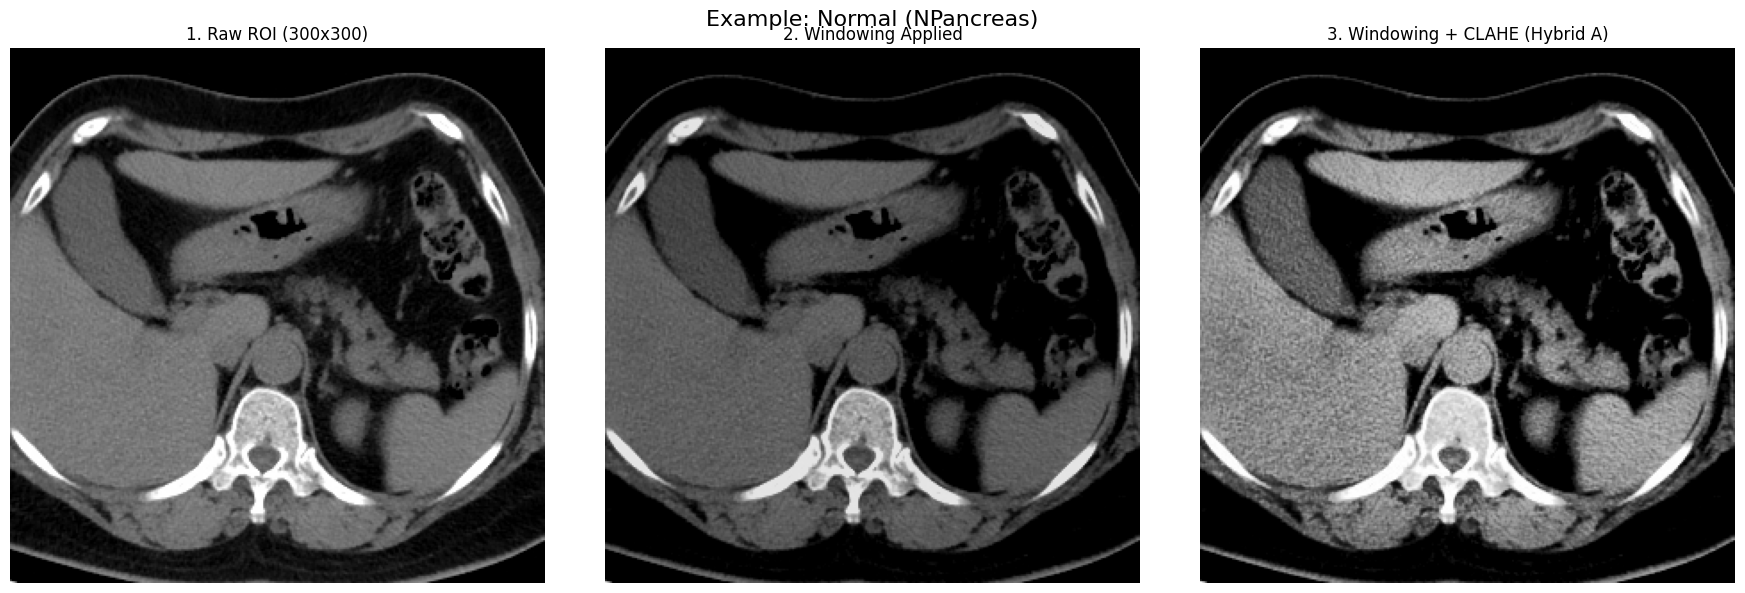

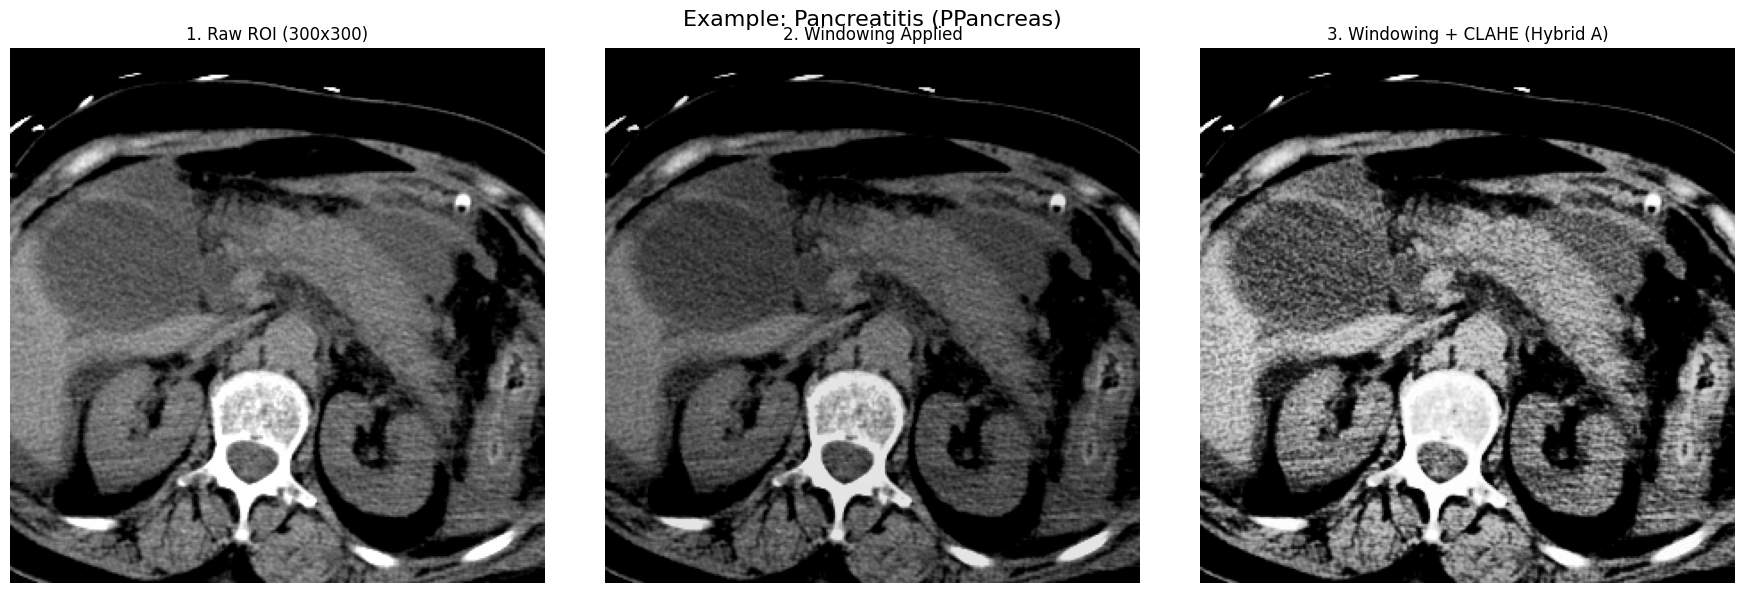

In [4]:
print("Starting Part 3: Preprocessing Visualization...")

def visualize_preprocessing(image_path, title):
    """Loads one image and plots the preprocessing steps."""
    try:
        # Load original 8-bit image
        img_8bit = np.array(Image.open(image_path).convert('L'))
        
        # --- Re-create the pipeline step-by-step for visualization ---
        
        # 1. Raw ROI
        raw_roi = get_raw_roi(image_path)
        if raw_roi.size == 0: 
            print(f"Could not process {image_path}")
            return
        
        # 2. Windowed (Full Image)
        windowed = apply_window(img_8bit, WINDOW_LEVEL, WINDOW_WIDTH)
        
        # 3. CLAHE (Full Image)
        clahe = exposure.equalize_adapthist(windowed / 255.0, clip_limit=CLIP_LIMIT, kernel_size=KERNEL_SIZE)
        clahe_8bit = (clahe * 255).astype(np.uint8)
        
        # 4. Hybrid A ROI (Cropped from CLAHE image)
        H, W = clahe_8bit.shape
        start_h, end_h = H // 2 - CENTER_CROP_SIZE // 2, H // 2 + CENTER_CROP_SIZE // 2
        start_w, end_w = W // 2 - CENTER_CROP_SIZE // 2, W // 2 + CENTER_CROP_SIZE // 2
        hybrid_a_roi = clahe_8bit[start_h:end_h, start_w:end_w]
        
        # --- Plotting ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(title, fontsize=16)
        
        axes[0].imshow(raw_roi, cmap='gray', vmin=0, vmax=255)
        axes[0].set_title(f"1. Raw ROI ({CENTER_CROP_SIZE}x{CENTER_CROP_SIZE})")
        axes[0].axis('off')

        axes[1].imshow(windowed[start_h:end_h, start_w:end_w], cmap='gray', vmin=0, vmax=255)
        axes[1].set_title("2. Windowing Applied")
        axes[1].axis('off')

        axes[2].imshow(hybrid_a_roi, cmap='gray', vmin=0, vmax=255)
        axes[2].set_title("3. Windowing + CLAHE (Hybrid A)")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error visualizing {image_path}: {e}")

# --- Find one example from each class ---
try:
    normal_path = glob.glob(os.path.join(PANCREAS_DATA_DIRECTORY, 'NPancreas', '*.JPG'))[0]
    pancreatitis_path = glob.glob(os.path.join(PANCREAS_DATA_DIRECTORY, 'PPancreas', '*.JPG'))[0]
    
    visualize_preprocessing(normal_path, "Example: Normal (NPancreas)")
    visualize_preprocessing(pancreatitis_path, "Example: Pancreatitis (PPancreas)")
except Exception as e:
    print(f"Could not find images for visualization. Check path: {PANCREAS_DATA_DIRECTORY}")
    print(e)

## Part 4: Classification using Preprocessed (Hybrid A) Images

Finally, we run the *exact same* classification, but this time we pass the `preprocess_and_roi_hybrid_a` function to the compiler. This will extract all features from the Windowed + CLAHE'd ROIs.

In [5]:
print("Starting Part 4: Classification on Hybrid A (Window + CLAHE) Images...")

# Compile features using the 'preprocess_and_roi_hybrid_a' function
X_hybrid, y_hybrid = compile_dataset_features(PANCREAS_DATA_DIRECTORY, preprocessing_function=preprocess_and_roi_hybrid_a)

if X_hybrid.size > 0:
    print("\n--- Example Feature Vector (Hybrid A) ---")
    print(f"Total feature vector length: {X_hybrid.shape[1]}")
    print(f"First 10 features from first image: {X_hybrid[0, :10]}\n")
    
    # Run the classification
    run_classification_pipeline(X_hybrid, y_hybrid, "Hybrid A (Window + CLAHE) Features")
else:
    print("\nFATAL ERROR: No features were extracted. Check PANCREAS_DATA_DIRECTORY path.")

Starting Part 4: Classification on Hybrid A (Window + CLAHE) Images...
Starting feature extraction using: preprocess_and_roi_hybrid_a
Found 410 files in 'NPancreas'.
Successfully extracted features from 410 images in 'NPancreas'.
Found 1350 files in 'PPancreas'.
Successfully extracted features from 1350 images in 'PPancreas'.

Feature Compilation Complete. X shape: (1760, 185), y shape: (1760,)

--- Example Feature Vector (Hybrid A) ---
Total feature vector length: 185
First 10 features from first image: [0.04472222 0.02521111 0.0163     0.00937778 0.00624444 0.00578889
 0.0054     0.0055     0.006      0.00848889]


    ✨ CLASSIFICATION RESULTS FOR: Hybrid A (Window + CLAHE) Features ✨
Training Set Size: 1408 samples
Testing Set Size: 352 samples

Training SVM Classifier (Linear Kernel)...
Training complete.

Overall Accuracy: 97.73%

--- Summary of Normalized Metrics ---
Normalized TP (Recall/Sensitivity): 97.78% (TP / Actual Positives)
Normalized TN (Specificity):        97.56% (TN 

## Part 5: Conclusion

Compare the **Overall Accuracy** from the report in Part 2 (Raw Images) and the report in Part 4 (Hybrid A Images). 

This will definitively tell you which feature pipeline is more effective for this specific classification task.